/tmp/ipykernel_533/3571067573.py:41: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_533/3571067573.py:41: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


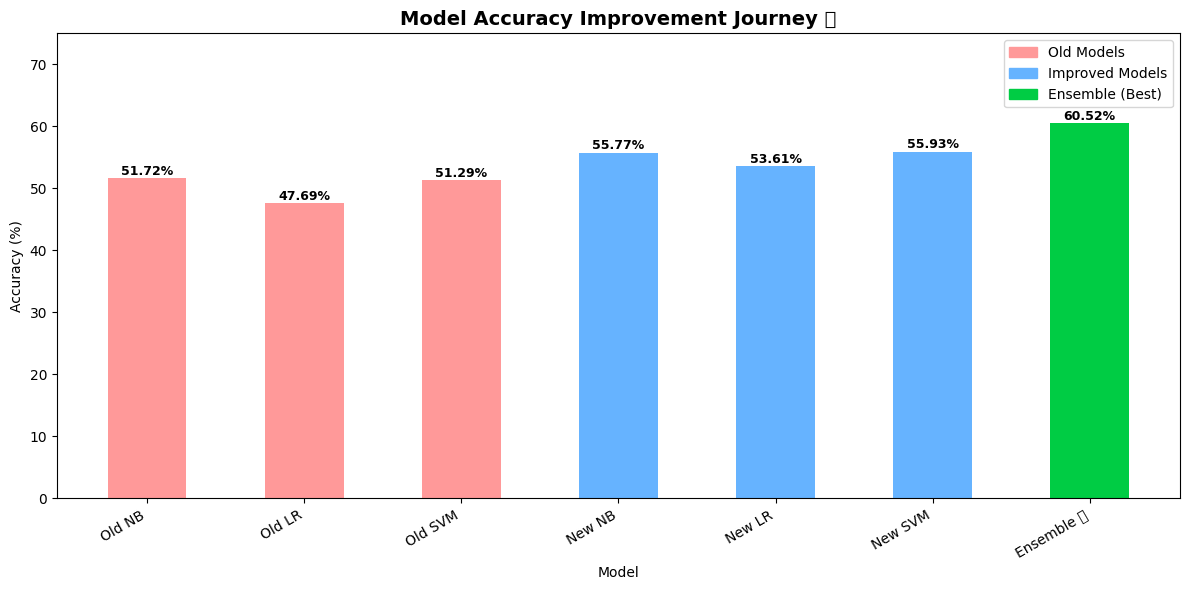


✅ TASK 1 FULLY COMPLETE!
Starting accuracy : 51.72%
Final accuracy    : 60.52%
Total improvement : +8.80%
Total movies      : 54,214
Total genres      : 27
Best model        : Ensemble (NB + LR + SVM)


In [ ]:
# Final comparison chart
all_results = {
    'Old NB'      : 0.5172,
    'Old LR'      : 0.4769,
    'Old SVM'     : 0.5129,
    'New NB'      : 0.5577,
    'New LR'      : 0.5361,
    'New SVM'     : 0.5593,
    'Ensemble 🏆' : 0.6052
}

colors = ['#ff9999','#ff9999','#ff9999',
          '#66b3ff','#66b3ff','#66b3ff',
          '#00cc44']

plt.figure(figsize=(12,6))
bars = plt.bar(all_results.keys(),
               [v*100 for v in all_results.values()],
               color=colors, width=0.5)

# Add percentage labels
for bar, val in zip(bars, all_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val*100:.2f}%',
             ha='center', fontweight='bold', fontsize=9)

plt.title('Model Accuracy Improvement Journey 🚀',
          fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 75)
plt.xticks(rotation=30, ha='right')

# Add legend
from matplotlib.patches import Patch
legend = [Patch(color='#ff9999', label='Old Models'),
          Patch(color='#66b3ff', label='Improved Models'),
          Patch(color='#00cc44', label='Ensemble (Best)')]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

print("\n✅ TASK 1 FULLY COMPLETE!")
print("="*45)
print(f"Starting accuracy : 51.72%")
print(f"Final accuracy    : 60.52%")
print(f"Total improvement : +8.80%")
print(f"Total movies      : 54,214")
print(f"Total genres      : 27")
print(f"Best model        : Ensemble (NB + LR + SVM)")

In [ ]:
def predict_genre_v2(plot_summary):
    cleaned    = clean_text_v2(plot_summary)
    vectorized = tfidf2.transform([cleaned])

    # Get prediction from all 3 models
    p1 = calibrated_svm.predict(vectorized)[0]
    p2 = cnb.predict(vectorized)[0]
    p3 = lr.predict(vectorized)[0]

    # Majority voting
    from collections import Counter
    votes = Counter([p1, p2, p3])
    final_genre = votes.most_common(1)[0][0]

    print(f"SVM voted       : {p1}")
    print(f"Naive Bayes voted: {p2}")
    print(f"Logistic Reg voted: {p3}")
    print(f"🏆 Final Genre  : {final_genre.upper()}")
    return final_genre

# Test with examples
examples = [
    "A young boy discovers he is a wizard and goes to a magical school",
    "Two people fall in love during a summer vacation on a beach",
    "A detective hunts a serial killer through dark city streets at night",
    "Aliens invade Earth and only one soldier can stop them with weapons",
    "A lion cub runs away after his father is killed and returns as a king"
]

print("🎬 IMPROVED Movie Genre Predictions")
print("="*60)
for plot in examples:
    print(f"\nPlot: {plot}")
    predict_genre_v2(plot)
    print("-"*60)

🎬 IMPROVED Movie Genre Predictions

Plot: A young boy discovers he is a wizard and goes to a magical school
SVM voted       : family
Naive Bayes voted: drama
Logistic Reg voted: family
🏆 Final Genre  : FAMILY
------------------------------------------------------------

Plot: Two people fall in love during a summer vacation on a beach
SVM voted       : drama
Naive Bayes voted: drama
Logistic Reg voted: romance
🏆 Final Genre  : DRAMA
------------------------------------------------------------

Plot: A detective hunts a serial killer through dark city streets at night
SVM voted       : thriller
Naive Bayes voted: horror
Logistic Reg voted: thriller
🏆 Final Genre  : THRILLER
------------------------------------------------------------

Plot: Aliens invade Earth and only one soldier can stop them with weapons
SVM voted       : sci-fi
Naive Bayes voted: sci-fi
Logistic Reg voted: sci-fi
🏆 Final Genre  : SCI-FI
------------------------------------------------------------

Plot: A lion cub r

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline

# Since LinearSVC doesn't support voting directly,
# we use CalibratedClassifierCV to fix that
from sklearn.calibration import CalibratedClassifierCV

print("Building ensemble model...")

# Calibrate SVM first
calibrated_svm = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', C=0.5, max_iter=2000)
)

# Train each model separately and combine predictions
print("Training SVM...")
calibrated_svm.fit(X_train2_vec, y_train2)
svm_preds = calibrated_svm.predict(X_val2_vec)

print("Training Complement NB...")
cnb = ComplementNB()
cnb.fit(X_train2_vec, y_train2)
cnb_preds = cnb.predict(X_val2_vec)

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=2000, class_weight='balanced', C=5, n_jobs=-1)
lr.fit(X_train2_vec, y_train2)
lr_preds = lr.predict(X_val2_vec)

# Majority voting
import pandas as pd
vote_df = pd.DataFrame({
    'svm': svm_preds,
    'cnb': cnb_preds,
    'lr' : lr_preds
})

# Each row votes for a genre — majority wins
ensemble_preds = vote_df.mode(axis=1)[0]
ensemble_acc = accuracy_score(y_val2, ensemble_preds)

print(f"\n✅ Ensemble Accuracy: {ensemble_acc:.4f}")
print(f"🏆 Improvement over best single model: +{(ensemble_acc - 0.5593)*100:.2f}%")

Building ensemble model...
Training SVM...
Training Complement NB...
Training Logistic Regression...

✅ Ensemble Accuracy: 0.6052
🏆 Improvement over best single model: +4.59%


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.calibration import CalibratedClassifierCV

models2 = {
    "Complement Naive Bayes": ComplementNB(),
    "Logistic Regression v2": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=5,              # stronger regularization
        solver='saga',    # faster solver for large data
        n_jobs=-1         # use all CPU cores
    ),
    "SVM v2": LinearSVC(
        class_weight='balanced',
        C=0.5,            # tuned parameter
        max_iter=2000
    )
}

results2 = {}

for name, model in models2.items():
    print(f"Training {name}...")
    model.fit(X_train2_vec, y_train2)
    preds = model.predict(X_val2_vec)
    acc = accuracy_score(y_val2, preds)
    results2[name] = acc
    print(f"✅ {name} Accuracy: {acc:.4f}\n")

best_name2 = max(results2, key=results2.get)
print(f"🏆 Best Model: {best_name2} with accuracy {results2[best_name2]:.4f}")

Training Complement Naive Bayes...
✅ Complement Naive Bayes Accuracy: 0.5577

Training Logistic Regression v2...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


✅ Logistic Regression v2 Accuracy: 0.5361

Training SVM v2...
✅ SVM v2 Accuracy: 0.5593

🏆 Best Model: SVM v2 with accuracy 0.5593


In [ ]:
X2 = train_df['clean_desc_v2']
y2 = train_df['Genre'].str.strip()

# Split data
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Better TF-IDF settings
tfidf2 = TfidfVectorizer(
    max_features=50000,    # more features (was 10000)
    ngram_range=(1,3),     # capture 3-word phrases too (was 1,2)
    sublinear_tf=True,     # reduces impact of very common words
    min_df=2,              # ignore very rare words
    max_df=0.95            # ignore words in 95%+ of documents
)

X_train2_vec = tfidf2.fit_transform(X_train2)
X_val2_vec   = tfidf2.transform(X_val2)

print("✅ Better TF-IDF done!")
print(f"Training matrix shape  : {X_train2_vec.shape}")
print(f"Validation matrix shape: {X_val2_vec.shape}")

✅ Better TF-IDF done!
Training matrix shape  : (43371, 50000)
Validation matrix shape: (10843, 50000)


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Apply new cleaning
train_df['clean_desc_v2'] = train_df['Description'].apply(clean_text_v2)

# Compare old vs new
print("OLD cleaning:")
print(train_df['clean_desc'][0][:200])
print("\nNEW cleaning:")
print(train_df['clean_desc_v2'][0][:200])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


OLD cleaning:
listening in to a conversation between his doctor and parents yearold oscar learns what nobody has the courage to tell him he only has a few weeks to live furious he refuses to speak to anyone except 

NEW cleaning:
listening conversation doctor parent yearold oscar learns nobody courage tell week live furious refuse speak anyone except straighttalking rose lady pink meet hospital stair christmas approach rose us


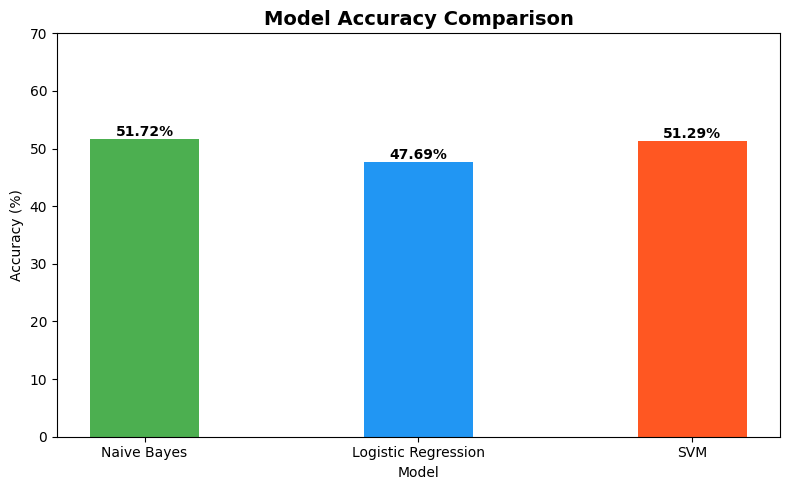


✅ PROJECT COMPLETE!
Naive Bayes        : 51.72%
Logistic Regression: 47.69%
SVM                : 51.29%

🏆 Best Model: Naive Bayes (51.72%)


In [ ]:
# Plot model comparison chart
plt.figure(figsize=(8,5))
colors = ['#4CAF50', '#2196F3', '#FF5722']
bars = plt.bar(results.keys(),
               [v*100 for v in results.values()],
               color=colors, width=0.4)

# Add percentage labels on bars
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val*100:.2f}%',
             ha='center', fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 70)
plt.tight_layout()
plt.show()

print("\n✅ PROJECT COMPLETE!")
print("="*40)
print(f"Naive Bayes        : {results['Naive Bayes']*100:.2f}%")
print(f"Logistic Regression: {results['Logistic Regression']*100:.2f}%")
print(f"SVM                : {results['SVM']*100:.2f}%")
print(f"\n🏆 Best Model: Naive Bayes ({results['Naive Bayes']*100:.2f}%)")

In [ ]:
def predict_genre(plot_summary):
    cleaned    = clean_text(plot_summary)
    vectorized = tfidf.transform([cleaned])
    genre      = best_model.predict(vectorized)[0]
    return genre

# Test with examples
examples = [
    "A young boy discovers he is a wizard and goes to a magical school",
    "Two people fall in love during a summer vacation on a beach",
    "A detective hunts a serial killer through dark city streets at night",
    "Aliens invade Earth and only one soldier can stop them with weapons",
    "A lion cub runs away after his father is killed and returns as a king"
]

print("🎬 Movie Genre Predictions")
print("="*60)
for plot in examples:
    genre = predict_genre(plot)
    print(f"\nPlot   : {plot}")
    print(f"Genre  : {genre.upper()}")
    print("-"*60)

🎬 Movie Genre Predictions

Plot   : A young boy discovers he is a wizard and goes to a magical school
Genre  : DRAMA
------------------------------------------------------------

Plot   : Two people fall in love during a summer vacation on a beach
Genre  : DRAMA
------------------------------------------------------------

Plot   : A detective hunts a serial killer through dark city streets at night
Genre  : HORROR
------------------------------------------------------------

Plot   : Aliens invade Earth and only one soldier can stop them with weapons
Genre  : DOCUMENTARY
------------------------------------------------------------

Plot   : A lion cub runs away after his father is killed and returns as a king
Genre  : DRAMA
------------------------------------------------------------


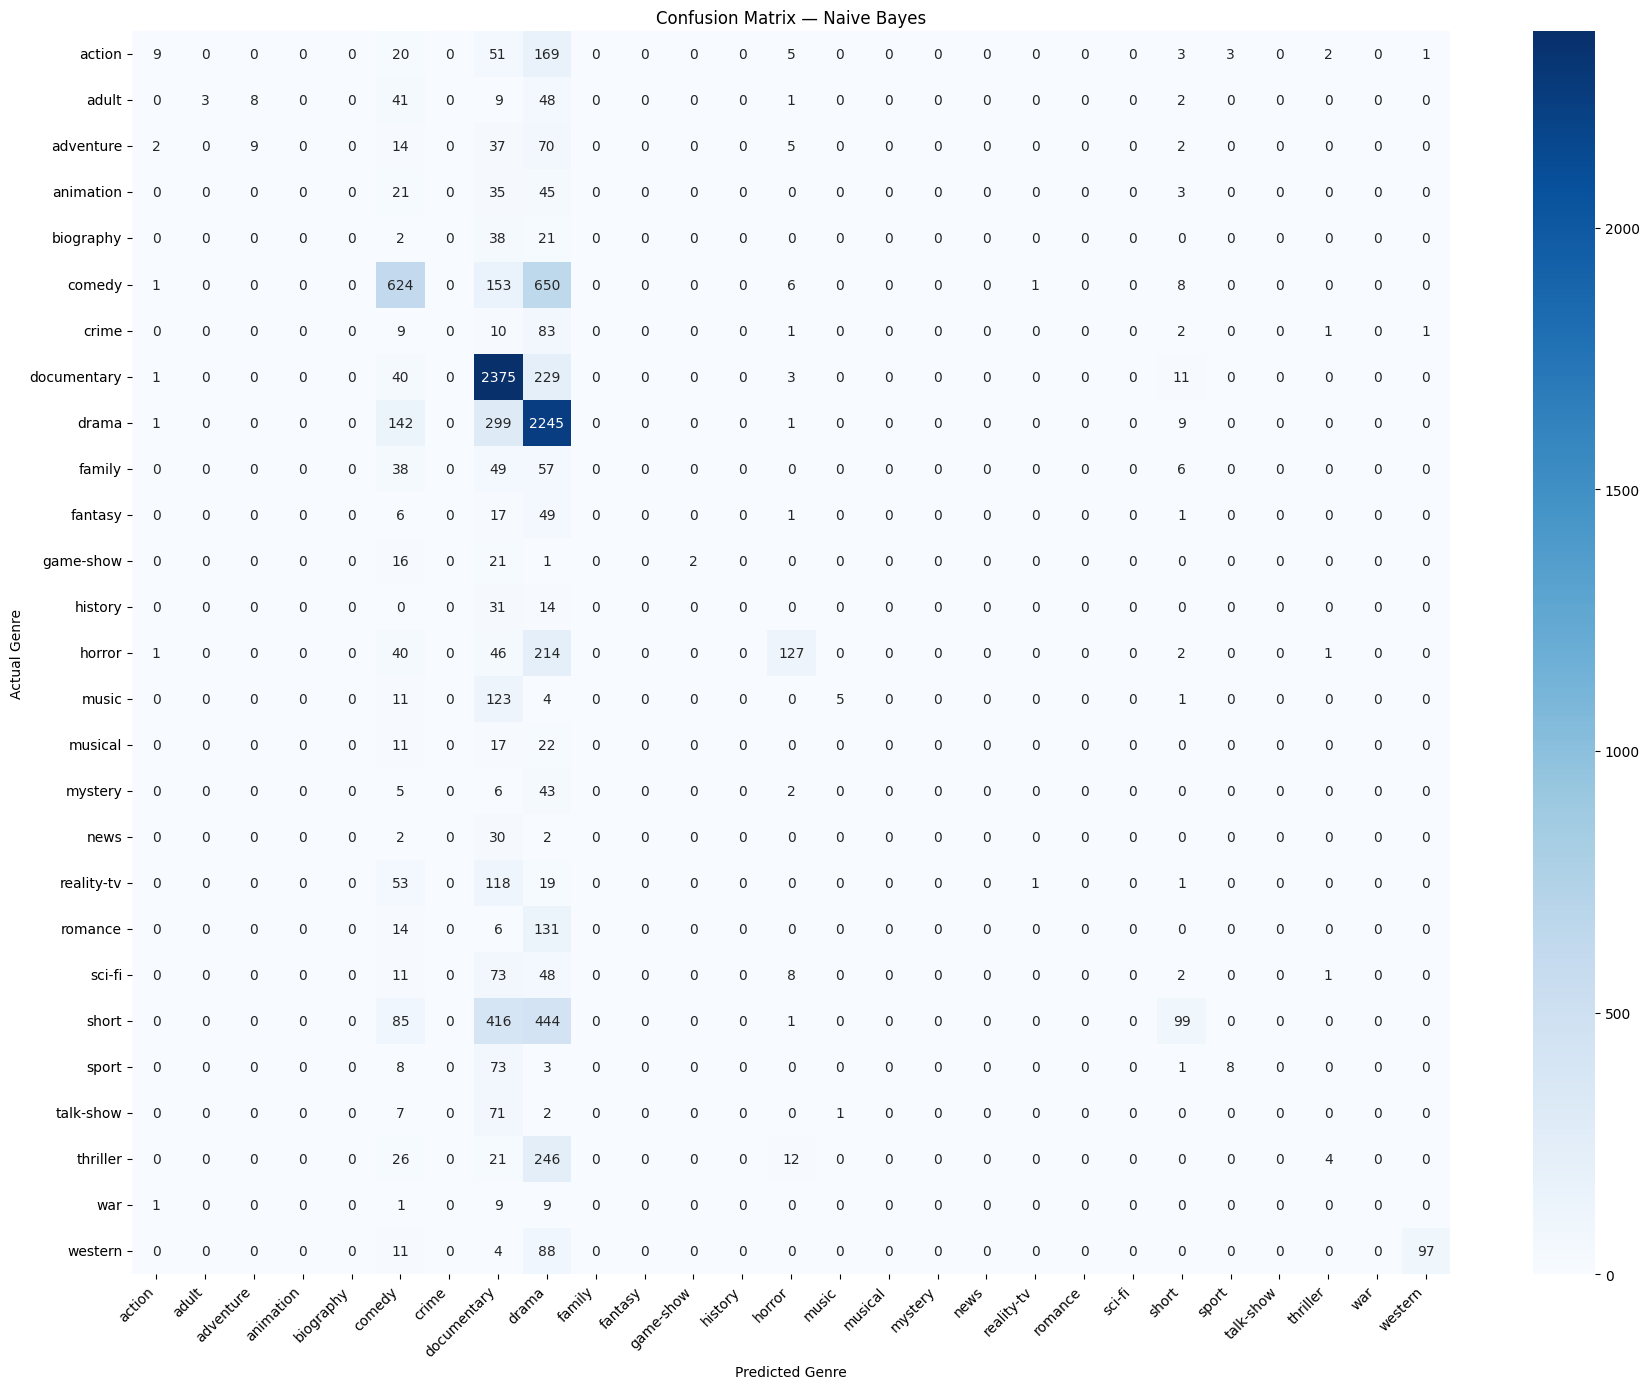

In [ ]:
# Use Naive Bayes as best model
best_model = models["Naive Bayes"]
preds = best_model.predict(X_val_vec)

# Plot confusion matrix
plt.figure(figsize=(18,14))
cm = confusion_matrix(y_val, preds, labels=best_model.classes_)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_,
            cmap='Blues')
plt.title('Confusion Matrix — Naive Bayes')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
models = {
    "Naive Bayes"        : MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM"                : LinearSVC(class_weight='balanced')
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_val_vec)
    acc = accuracy_score(y_val, preds)
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc:.4f}\n")

# Show best model
best_name = max(results, key=results.get)
print(f"🏆 Best Model: {best_name} with accuracy {results[best_name]:.4f}")

Training Naive Bayes...
✅ Naive Bayes Accuracy: 0.5172

Training Logistic Regression...
✅ Logistic Regression Accuracy: 0.4769

Training SVM...
✅ SVM Accuracy: 0.5129

🏆 Best Model: Naive Bayes with accuracy 0.5172


In [ ]:
# Convert text into numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2))

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec   = tfidf.transform(X_val)

print("TF-IDF done!")
print(f"Training matrix shape  : {X_train_vec.shape}")
print(f"Validation matrix shape: {X_val_vec.shape}")

TF-IDF done!
Training matrix shape  : (43371, 10000)
Validation matrix shape: (10843, 10000)


In [ ]:
X = train_df['clean_desc']         # input: plot summaries
y = train_df['Genre'].str.strip()  # output: genres

# Split into training and validation sets (80% train, 20% test)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total samples     : {len(X)}")
print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Total samples     : 54214
Training samples  : 43371
Validation samples: 10843


In [ ]:
def clean_text(text):
    text = str(text).lower()                 # make lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # remove numbers & symbols
    text = text.strip()                      # remove extra spaces
    return text

# Apply cleaning to descriptions
train_df['clean_desc'] = train_df['Description'].apply(clean_text)

# Compare before and after
print("BEFORE cleaning:")
print(train_df['Description'][0])
print("\nAFTER cleaning:")
print(train_df['clean_desc'][0])

BEFORE cleaning:
 Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody has the courage to tell him. He only has a few weeks to live. Furious, he refuses to speak to anyone except straight-talking Rose, the lady in pink he meets on the hospital stairs. As Christmas approaches, Rose uses her fantastical experiences as a professional wrestler, her imagination, wit and charm to allow Oscar to live life and love to the full, in the company of his friends Pop Corn, Einstein, Bacon and childhood sweetheart Peggy Blue.

AFTER cleaning:
listening in to a conversation between his doctor and parents yearold oscar learns what nobody has the courage to tell him he only has a few weeks to live furious he refuses to speak to anyone except straighttalking rose the lady in pink he meets on the hospital stairs as christmas approaches rose uses her fantastical experiences as a professional wrestler her imagination wit and charm to allow oscar to live life an

Total genres: 27

Movies per genre:
Genre
drama           13613
documentary     13096
comedy           7447
short            5073
horror           2204
thriller         1591
action           1315
western          1032
reality-tv        884
family            784
adventure         775
music             731
romance           672
sci-fi            647
adult             590
crime             505
animation         498
sport             432
talk-show         391
fantasy           323
mystery           319
musical           277
biography         265
history           243
game-show         194
news              181
war               132
Name: count, dtype: int64


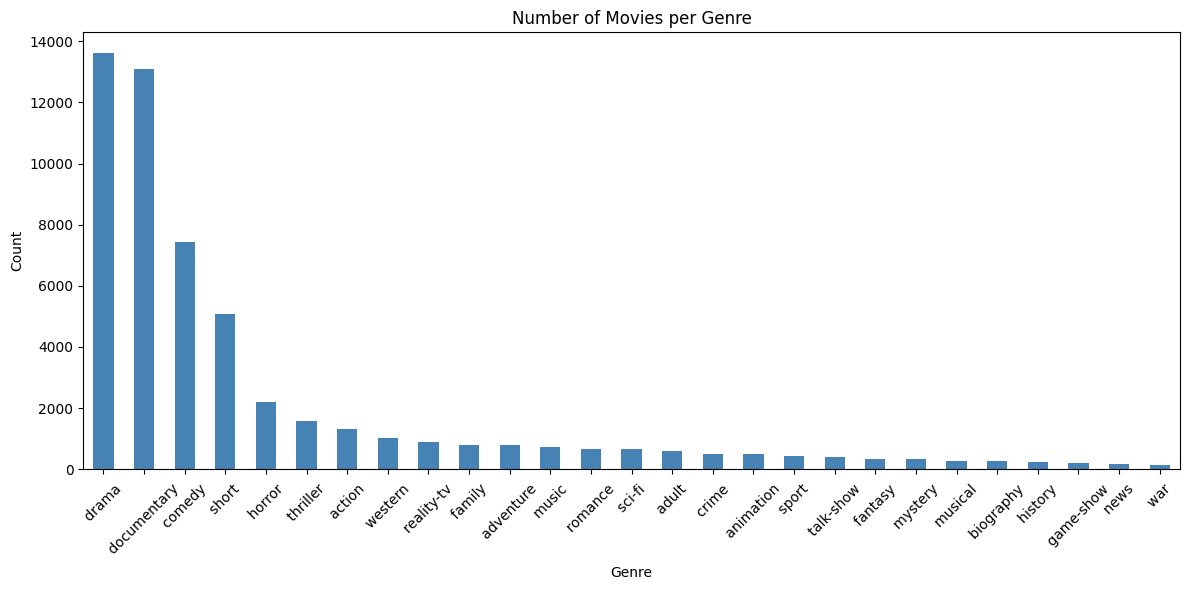

In [ ]:
# See how many movies per genre
print("Total genres:", train_df['Genre'].nunique())
print("\nMovies per genre:")
print(train_df['Genre'].value_counts())

# Plot it
plt.figure(figsize=(12,6))
train_df['Genre'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'test_data.txt', 'test_data_solution.txt', 'train_data.txt', 'description.txt', 'sample_data']


In [ ]:
# Load training data
train_df = pd.read_csv('train_data.txt',
                        sep=':::',
                        names=['ID', 'Title', 'Genre', 'Description'],
                        engine='python')

# Load test data
test_df = pd.read_csv('test_data.txt',
                       sep=':::',
                       names=['ID', 'Title', 'Description'],
                       engine='python')

# Preview the data
print("Training data shape:", train_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())

Training data shape: (54214, 4)

First 5 rows:
   ID                               Title       Genre  \
0   1       Oscar et la dame rose (2009)       drama    
1   2                       Cupid (1997)    thriller    
2   3   Young, Wild and Wonderful (1980)       adult    
3   4              The Secret Sin (1915)       drama    
4   5             The Unrecovered (2007)       drama    

                                         Description  
0   Listening in to a conversation between his do...  
1   A brother and sister with a past incestuous r...  
2   As the bus empties the students for their fie...  
3   To help their unemployed father make ends mee...  
4   The film's title refers not only to the un-re...  


In [ ]:
# Install any missing library
!pip install scikit-learn pandas numpy matplotlib seaborn

# Import everything we need
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries loaded successfully!")


All libraries loaded successfully!
